In [2]:
import polars as pl
import os
from PIL import Image

BASEPATH = "/home/affahrizain/projects/datasets/geotir"

In [3]:
df = pl.read_csv(os.path.join(BASEPATH, "jp_gldv_mp16_merged_scenetags.csv"))
df.head()

row_idx,id,latitude,longitude,country_code,country,region,subregion,city,ratio,threshold,is_landmark,category,dataset,src,scene_type,viewpoint_type,reasoning,error
i64,str,f64,f64,str,str,str,str,str,f64,f64,bool,str,str,str,str,str,str,str
12,"""c8c873b700bb6526""",35.681028,139.763778,"""JP""","""Japan""","""Asia""","""Eastern Asia""","""Tokyo""",0.866004,0.15,true,"""tower""","""gldv2-full""","""train""","""outdoor""","""aerial""","""The image clearly depicts an o…",null
37,"""cf724c3632280892""",34.673972,133.299944,"""JP""","""Japan""","""Asia""","""Eastern Asia""","""Fuchucho""",0.181179,0.15,true,null,"""gldv2-full""","""train""","""outdoor""","""ground""","""The image clearly shows an out…",null
21,"""93c22dd3dcfd2ec8""",34.6712,135.146995,"""JP""","""Japan""","""Asia""","""Eastern Asia""","""Kobe""",0.334974,0.15,true,"""shinto shrine""","""gldv2-full""","""train""","""outdoor""","""ground""","""The image clearly shows an out…",null
10,"""5ea77bed6c2c7261""",34.9925,135.684167,"""JP""","""Japan""","""Asia""","""Eastern Asia""","""Muko""",0.085083,0.15,false,"""temple""","""gldv2-full""","""train""","""outdoor""","""ground""","""The image clearly depicts an o…",null
17,"""f696b4b0f673944d""",32.213333,130.752778,"""JP""","""Japan""","""Asia""","""Eastern Asia""","""Hitoyoshi""",0.510129,0.15,true,"""shinto shrine""","""gldv2-full""","""train""","""outdoor""","""ground""","""The image clearly shows an out…",null


In [ ]:
excl = [
    "8f3e0d9bbd27a731",
    "ec_7f_4971048418",
]

df.filter(~pl.col("id").is_in(excl))

row_idx,id,latitude,longitude,country_code,country,region,subregion,city,ratio,threshold,is_landmark,category,dataset,src,scene_type,viewpoint_type,reasoning,error
i64,str,f64,f64,str,str,str,str,str,f64,f64,bool,str,str,str,str,str,str,str
97719,"""8f3e0d9bbd27a731""",35.695,139.760833,"""JP""","""Japan""","""Asia""","""Eastern Asia""","""Tokyo""",0.00164,0.15,false,"""tower""","""gldv2-full""","""index""","""indoor""","""ground""","""The image clearly depicts an i…",null
121966,"""ec_7f_4971048418""",35.667575,139.761416,"""JP""","""Japan""","""Asia""","""Eastern Asia""","""Tokyo""",0.0,0.15,false,null,"""mp16""","""images""","""indoor""","""ground""","""Step 1: The image is clearly c…",null


In [ ]:
# [list(st.values()) for st in stats]
# {v: d["len"] for d in stats for k, v in d.items() if k != "len"}

{'indoor': 39990, 'outdoor': 178710, 'aerial': 7752, 'ground': 210948}

In [6]:
df["scene_type"].unique(), df["viewpoint"].unique()

(shape: (3,)
 Series: 'scene_type' [str]
 [
 	"indoor"
 	"ambiguous"
 	"outdoor"
 ],
 shape: (5,)
 Series: 'viewpoint' [str]
 [
 	"other"
 	"aerial_overhead"
 	"interior"
 	"exterior_facing_landmark"
 	"from_landmark_top"
 ])

In [66]:
exteriors = (
    df.filter(pl.col("is_semantically_salient") & pl.col("is_structurally_salient"))
    .filter(pl.col("scene_type") != "ambiguous")
    .filter(pl.col("viewpoint").is_in(["interior", "exterior_facing_landmark"]))
    .filter(pl.col("landmark_category") != "non_landmark")
    .to_dicts()
)
len(exteriors)

159390

In [86]:
"sasata.jpg".endswith(".jpg")

True

In [89]:
df.filter(pl.col("is_semantically_salient") & pl.col("is_structurally_salient")).filter(
    pl.col("scene_type") != "ambiguous"
).filter(pl.col("viewpoint").is_in(["interior", "exterior_facing_landmark"])).filter(
    pl.col("landmark_category") != "non_landmark"
).unique("id").with_columns(
    pl.col("id").map_elements(lambda x: x.strip(".jpg") if x.endswith(".jpg") else x)
).drop("row_idx").write_csv(os.path.join(BASEPATH, "jp_saliency_clean.csv"))

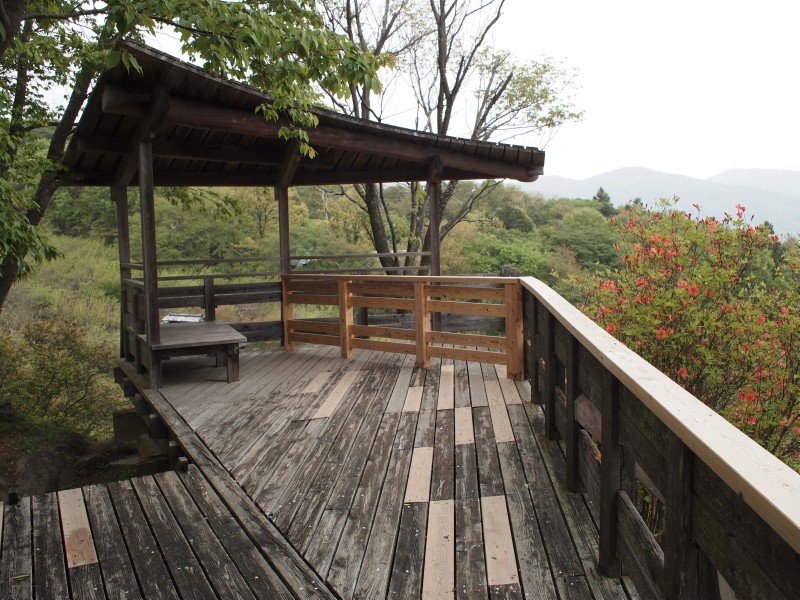

In [80]:
item = exteriors[13]
Image.open(
    os.path.join(
        BASEPATH,
        item["dataset"],
        item["src"],
        (f"{item['id']}.jpg" if item["dataset"] == "gldv2-full" else f"{item['id']}"),
    )
)

In [11]:
import polars as pl
from sklearn.model_selection import train_test_split
from PIL import Image

df = pl.read_csv(os.path.join(BASEPATH, "jp_saliency_clean.csv"))
df.head()

id,latitude,longitude,country_code,country,region,subregion,city,ratio,threshold,is_landmark,category,dataset,src,category_reasoning,landmark_category,visual_reasoning,landmark_coverage,semantic_reasoning,is_semantically_salient,semantic_confidence,structural_reasoning,scene_type,viewpoint,is_structurally_salient,structural_confidence,error,caption
str,f64,f64,str,str,str,str,str,f64,f64,bool,str,str,str,str,str,str,f64,str,bool,f64,str,str,str,bool,f64,str,str
"""52_cf_5053169213""",35.669107,139.77981,"""JP""","""Japan""","""Asia""","""Eastern Asia""","""Tokyo""",0.0,0.15,false,null,"""mp16""","""images""","""The image displays a tradition…","""shinto_shrine""","""The structure occupies approxi…",0.45,"""This is a real photograph of a…",true,0.98,"""The photograph is taken from a…","""outdoor""","""exterior_facing_landmark""",true,0.99,"""A traditional wooden Shinto sh…",null
"""6c5a9ebea2877303""",34.6539,135.117,"""JP""","""Japan""","""Asia""","""Eastern Asia""","""Kobe""",0.044677,0.15,false,"""garden""","""gldv2-full""","""train""","""The image displays a grand, sy…","""palace""","""The main architectural structu…",0.85,"""This is a real photograph of a…",true,0.98,"""The photograph is taken from a…","""outdoor""","""exterior_facing_landmark""",true,0.99,null,null
"""afdfbc150bbeb4cd""",35.157222,136.899444,"""JP""","""Japan""","""Asia""","""Eastern Asia""","""Nagoya-shi""",0.143158,0.15,false,"""temple""","""gldv2-full""","""train""","""The image displays a tradition…","""shinto_shrine""","""The structure occupies approxi…",0.65,"""This is a real photograph of a…",true,0.98,"""The photograph is taken from a…","""outdoor""","""exterior_facing_landmark""",true,0.99,null,null
"""d0_db_9632354627""",35.487258,139.62593,"""JP""","""Japan""","""Asia""","""Eastern Asia""","""Yokohama""",0.0,0.15,false,null,"""mp16""","""images""","""The image displays a large, na…","""garden""","""The main architectural structu…",0.05,"""This is a real photograph of a…",true,0.98,"""The photograph is taken from a…","""outdoor""","""exterior_facing_landmark""",true,0.99,"""A large stone sign reading 'GA…",null
"""57_55_3054446670""",35.431313,139.40202,"""JP""","""Japan""","""Asia""","""Eastern Asia""","""Atsugi""",0.69042,0.15,true,null,"""mp16""","""images""","""The image displays a small, re…","""shinto_shrine""","""The structure occupies approxi…",0.45,"""This is a real photograph of a…",true,0.98,"""The photograph is taken from o…","""outdoor""","""exterior_facing_landmark""",true,0.99,"""A small, rectangular wooden Sh…",null


In [9]:
df.group_by(pl.col("scene_type")).agg(pl.len())

scene_type,len
str,u32
"""outdoor""",134695
"""indoor""",8975


In [10]:
train, test = train_test_split(df, test_size=0.05, stratify=df["viewpoint"])
train, val = train_test_split(train, test_size=0.1, stratify=train["viewpoint"])

len(train), len(val), len(test)

(122837, 13649, 7184)

In [23]:
import sys

sys.path.append("..")
from src.viewpoint.model import ViewpointClassifier
from src.viewpoint.train import run_inference, ImageDataset
from torch.utils.data import DataLoader
from torchvision import transforms
import torch

device = "cuda"

In [24]:
model = ViewpointClassifier(nclass=2).to(device)
model.load_state_dict(
    torch.load(
        "../checkpoints/viewpoint_exp2_lr1e-2/viewpoint_best.pt",
    )
)
model.eval()

ViewpointClassifier(
  (base_model): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (relu): ReLU

In [ ]:
transform_fn = transforms.Compose(
    [
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ]
)

dataset = ImageDataset(
    test, base_img_path="../../datasets/geotir/", transform=transform_fn
)
testloader = DataLoader(dataset, 64, shuffle=False, num_workers=4)

In [26]:
from tqdm.auto import tqdm

all_labels = []
all_preds = []

for inp, lbl in tqdm(testloader, desc="Inference"):
    inp, lbl = inp.to(device), lbl.to(device)
    out = model(inp)
    preds = torch.argmax(out, dim=1)

    all_preds.append(preds.cpu())
    all_labels.append(lbl.cpu())

all_preds = torch.cat(all_preds).numpy()
all_labels = torch.cat(all_labels).numpy()

Inference: 100%|██████████| 113/113 [01:00<00:00,  1.86it/s]


In [ ]:
from sklearn.metrics import precision_recall_fscore_support

LABEL2ID = {"interior": 0, "exterior_facing_landmark": 1}

precision, recall, f1, _ = precision_recall_fscore_support(
    all_labels,
    all_preds,
    average="macro",
    pos_label=LABEL2ID["exterior_facing_landmark"],
)

In [ ]:
test = test.with_columns(
    pl.Series(["outdoor" if i == 1 else "indoor" for i in all_labels.tolist()]).alias(
        "predicted_labels"
    )
)

In [57]:
test.filter(pl.col("predicted_labels") == "indoor").head().to_dicts()

[{'id': '6f_0f_2486061740',
  'latitude': 35.627529,
  'longitude': 139.773731,
  'country_code': 'JP',
  'country': 'Japan',
  'region': 'Asia',
  'subregion': 'Eastern Asia',
  'city': 'Tokyo',
  'ratio': 0.0,
  'threshold': 0.15,
  'is_landmark': False,
  'category': None,
  'dataset': 'mp16',
  'src': 'images',
  'category_reasoning': "The image displays a large, multi-tiered wooden structure resembling a traditional Japanese boat or float, adorned with red foliage, lanterns, and decorative elements. It is situated indoors, likely in a museum or exhibition hall, surrounded by glass barriers. The structure features a prominent hull with blue and white wave patterns, a raised deck with seating or platforms, and a decorative canopy. The setting includes other exhibits and display cases in the background, indicating a public cultural space. The structure is clearly a man-made architectural object designed for display, fitting the category of a 'garden' or 'parks' in the context of a pu

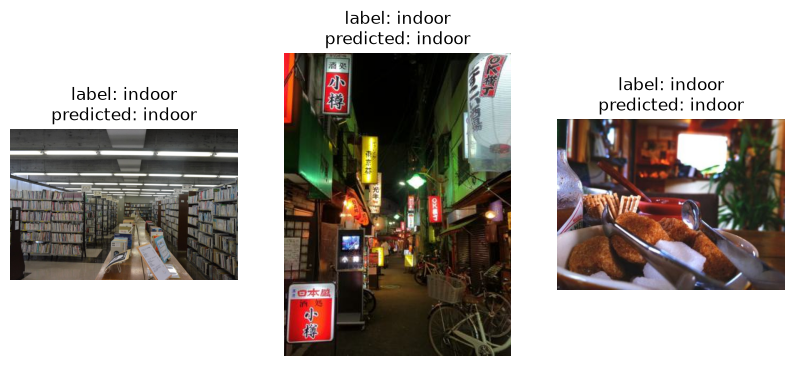

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 3, figsize=(10, 5))
for i, item in enumerate(
    test.filter(pl.col("predicted_labels") == "indoor").sample(3).to_dicts()
):
    ax[i].imshow(
        Image.open(
            os.path.join(
                "../../datasets/geotir/",
                item["dataset"],
                item["src"],
                f"{item['id']}.jpg",
            )
        )
    )
    ax[i].axis("off")
    ax[i].set_title(
        f"label: {item['scene_type']}\npredicted: {item['predicted_labels']}"
    )

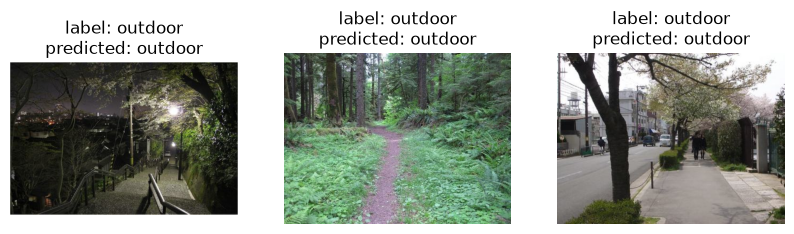

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(10, 5))
for i, item in enumerate(
    test.filter(pl.col("predicted_labels") == "outdoor").sample(3).to_dicts()
):
    ax[i].imshow(
        Image.open(
            os.path.join(
                "../../datasets/geotir/",
                item["dataset"],
                item["src"],
                f"{item['id']}.jpg",
            )
        )
    )
    ax[i].axis("off")
    ax[i].set_title(
        f"label: {item['scene_type']}\npredicted: {item['predicted_labels']}"
    )